In [2]:
features_dir = '/Users/kesiyun/Desktop/Thesis/github/features/01SF_sw' 
extra_features_dir = '/Users/kesiyun/Desktop/Thesis/github/features/01SF_sw_aug'
split_path = '/Users/kesiyun/Desktop/Thesis/github/config/00full_video_split_5s.json'
json_path = '/Users/kesiyun/Desktop/Thesis/github/config/00sequenceresult.json'



import os
import json
import re
import glob

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset, random_split

import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, f1_score
import numpy as np


# Utility functions
def read_json(path):
    with open(path, 'r') as f:
        return json.load(f)

def get_training_weight(train_loader):
    def get_loader_stats(loader, name):
        weight_out=[]
        
        label_counts = {}
        feature_shapes = {}
        total_samples = 0

        for batch in loader:
            features, labels = batch
            total_samples += len(labels)

            for feature, label in zip(features, labels):
                label_val = label.item()
                label_counts[label_val] = label_counts.get(label_val, 0) + 1

                shape = tuple(feature.shape)
                feature_shapes[shape] = feature_shapes.get(shape, 0) + 1
        
        for label, count in sorted(label_counts.items()):
            weight_out.append(count)
            #print(f"    Label {label}: {count} samples")
        return weight_out
    return get_loader_stats(train_loader, "Training")    

def print_loader_metadata(train_loader, test_loader):
    def get_loader_stats(loader, name):
        label_counts = {}
        feature_shapes = {}
        total_samples = 0

        for batch in loader:
            features, labels = batch
            total_samples += len(labels)

            for feature, label in zip(features, labels):
                label_val = label.item()
                label_counts[label_val] = label_counts.get(label_val, 0) + 1

                shape = tuple(feature.shape)
                feature_shapes[shape] = feature_shapes.get(shape, 0) + 1

        print(f"\n{name} Loader:")
        print(f"  Total samples: {total_samples}")
        print(f"  Total batches (batch_size={loader.batch_size}): {len(loader)}")
        print(f"  Feature shape(s):")
        for shape, count in feature_shapes.items():
            print(f"    Shape {shape}: {count} samples")
        print(f"  Label distribution:")
        for label, count in sorted(label_counts.items()):
            print(f"    Label {label}: {count} samples")

    get_loader_stats(train_loader, "Training")
    get_loader_stats(test_loader, "Testing")

def get_final_D_cutoff_seconds(meta_for_video):
    """
    Parse the final D(mm:ss) from the 'timesec' string.
    Returns the cutoff in integer seconds, or None if there is no D.
    """
    if not meta_for_video:
        return None
    ts = meta_for_video.get('timesec', '')
    # Find ALL occurrences of D(mm:ss); use the last one as the cutoff.
    matches = list(re.finditer(r'D\((\d+):(\d+)\)', ts))
    if not matches:
        return None
    m = matches[-1]
    minutes = int(m.group(1))
    seconds = int(m.group(2))
    return minutes * 60 + seconds  # total seconds


def parse_augmented_filename(fname):
    """
    Parse names like '99A_0056_X.pt' into (base_id, timestamp_seconds, tag_suffix).
    - If timestamp token is 4 digits, interpret as MMSS.
    - Else if it's an integer string, interpret as total seconds.
    Returns (base_id, timestamp_seconds or None, tag_suffix or None).
    """
    stem = os.path.splitext(os.path.basename(fname))[0]  # e.g., '99A_0056_X'
    parts = stem.split('_')
    base = parts[0] if parts else None
    ts_seconds = None
    tag = parts[-1] if len(parts) >= 3 else (parts[1] if len(parts) == 2 else None)

    if len(parts) >= 2:
        ts_token = parts[1]
        if ts_token.isdigit():
            if len(ts_token) == 4:        # MMSS
                mm = int(ts_token[:2])
                ss = int(ts_token[2:])
                ts_seconds = mm * 60 + ss
            else:                          # total seconds
                ts_seconds = int(ts_token)

    return base, ts_seconds, tag


In [3]:

# =============================
# Load splits & metadata (same variables you used)
# =============================
import os
import json
import torch

# Paths (keep as-is; edit only if you moved your data)
#features_dir = ''
#split_path   = ''



# Uses your helper read_json() defined earlier
loaded_result = read_json(json_path)
dataset_split = read_json(split_path)

training_split = dataset_split['training_set']
test_split     = dataset_split['testing_set']

print(f"Train video IDs: {len(training_split)} | Test video IDs: {len(test_split)}")


Train video IDs: 51 | Test video IDs: 6


In [8]:
#fuse aug

In [9]:

# =============================
# Reproducibility + pathway slicing + threshold
# =============================
import random
import numpy as np
import torch

seed = 3407
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pathway slicing configuration (same knobs as your baseline)
TOTAL_DIM = 2304          # full feature length
FAST_DIM  = 256           # fast pathway size
SLOW_DIM  = TOTAL_DIM - FAST_DIM  # typically 2048 if TOTAL_DIM=2304

SELECT_PATHWAY = "fast"   # Options: 'fast', 'slow', 'custom'
THRESHOLD = 0.5           # Default threshold

# Custom slicing indices if needed
CUSTOM_START = 0
CUSTOM_END   = TOTAL_DIM  # end is exclusive

def get_feature_slice(total_dim=TOTAL_DIM, fast_dim=FAST_DIM, slow_dim=SLOW_DIM):
    if SELECT_PATHWAY == "fast":
        return slice(total_dim - fast_dim, total_dim)
    elif SELECT_PATHWAY == "slow":
        return slice(0, slow_dim)
    elif SELECT_PATHWAY == "custom":
        return slice(CUSTOM_START, CUSTOM_END)
    else:
        raise ValueError("SELECT_PATHWAY must be 'fast', 'slow', or 'custom'.")

feature_slice = get_feature_slice()
print("Using feature slice:", feature_slice, "| SELECT_PATHWAY =", SELECT_PATHWAY, "| THRESHOLD =", THRESHOLD)


Using feature slice: slice(2048, 2304, None) | SELECT_PATHWAY = fast | THRESHOLD = 0.5


In [10]:

# =============================
# Sequence dataset per video (respects cutoff + slicing)
# =============================
from torch.utils.data import Dataset

class SequenceDataset(Dataset):
    """
    Loads full time-ordered sequences per video (.pt list of (feat[1, 2304], label_int)).
    Applies cutoff rule: after the last D(mm:ss) in metadata, labels become 0.
    Returns per item:
      - X_seq: FloatTensor [T, D_in] (with feature_slice applied)
      - y_seq: FloatTensor [T, 1]
    """
    def __init__(self, video_names, features_root, meta_result_dict, feature_slice, apply_cutoff=True, skip_list=None):
        self.video_names = [vn for vn in video_names if (skip_list is None or vn not in skip_list)]
        self.features_root = features_root
        self.meta_result_dict = meta_result_dict
        self.feature_slice = feature_slice
        self.apply_cutoff = apply_cutoff

        self.seqs   = []  # List[Tensor [T, D_in]]
        self.labels = []  # List[Tensor [T, 1]]
        self._load_all()

    def _load_all(self):
        for video_name in self.video_names:
            pt_path = os.path.join(self.features_root, video_name + '.pt')
            feature_list = torch.load(pt_path)  # list of tuples: (feat[1, TOTAL_DIM], label_int)
            cutoff_seconds = get_final_D_cutoff_seconds(self.meta_result_dict.get(video_name))

            x_list, y_list = [], []
            for i in range(len(feature_list)):
                feature_this = feature_list[i][0]  # [1, TOTAL_DIM]
                label_this   = feature_list[i][1]  # int 0/1

                if self.apply_cutoff and (cutoff_seconds is not None):
                    second_index = i + 1  # entries per second
                    if second_index > cutoff_seconds:
                        label_this = 0

                # apply feature slice
                x_list.append(feature_this[:, feature_slice])  # [1, D_in]
                y_list.append([float(label_this)])             # [1]

            if len(x_list) == 0:
                continue

            X_seq = torch.cat(x_list, dim=0).contiguous()     # [T, D_in]
            y_seq = torch.tensor(y_list).float().contiguous() # [T, 1]
            self.seqs.append(X_seq)
            self.labels.append(y_seq)

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        return self.seqs[idx], self.labels[idx]

# Build datasets from your split
skip_test = []  # e.g., ['16A'] to skip if desired

full_train_seq_ds = SequenceDataset(
    video_names=training_split,
    features_root=features_dir,
    meta_result_dict=loaded_result,
    feature_slice=feature_slice,
    apply_cutoff=True
)

test_seq_ds = SequenceDataset(
    video_names=[vn for vn in test_split if vn not in skip_test],
    features_root=features_dir,
    meta_result_dict=loaded_result,
    feature_slice=feature_slice,
    apply_cutoff=True
)

print(f"Train videos loaded: {len(full_train_seq_ds)} | Test videos loaded: {len(test_seq_ds)}")
if len(full_train_seq_ds) == 0:
    raise RuntimeError("No training sequences found. Check paths or feature files.")


Train videos loaded: 51 | Test videos loaded: 6


In [11]:

# =============================
# Collate (pad + mask) and DataLoaders; compute pos_weight
# =============================
from torch.utils.data import DataLoader, random_split
import torch

def pad_collate_fn(batch):
    """
    batch: list of (X[T_i, D], y[T_i, 1])
    Returns:
      X_pad:   [B, T_max, D]
      y_pad:   [B, T_max, 1]
      mask:    [B, T_max] (bool; True for valid)
      lengths: [B]
    """
    Xs, ys = zip(*batch)
    lengths = torch.tensor([x.shape[0] for x in Xs], dtype=torch.long)
    T_max = int(lengths.max().item())
    B = len(Xs)
    D = Xs[0].shape[1]

    X_pad = Xs[0].new_zeros((B, T_max, D))
    y_pad = ys[0].new_zeros((B, T_max, 1))
    mask  = torch.zeros((B, T_max), dtype=torch.bool)

    for i, (x, y) in enumerate(zip(Xs, ys)):
        t = x.shape[0]
        X_pad[i, :t] = x
        y_pad[i, :t] = y
        mask[i, :t]  = True

    return X_pad, y_pad, mask, lengths

# Video-level virtual split from training data
generator = torch.Generator().manual_seed(seed)
train_size = int(0.8 * len(full_train_seq_ds))
val_size   = len(full_train_seq_ds) - train_size
train_seq_ds, val_seq_ds = random_split(full_train_seq_ds, [train_size, val_size], generator=generator)

batch_size = 32
train_loader = DataLoader(train_seq_ds, batch_size=batch_size, shuffle=True,  collate_fn=pad_collate_fn)
val_loader   = DataLoader(val_seq_ds,   batch_size=batch_size, shuffle=False, collate_fn=pad_collate_fn)
test_loader  = DataLoader(test_seq_ds,  batch_size=batch_size, shuffle=False, collate_fn=pad_collate_fn)

def compute_pos_weight_from_loader(loader):
    pos, neg = 0, 0
    for X_pad, y_pad, mask, _ in loader:
        y_valid = y_pad[mask].view(-1)
        pos += (y_valid == 1).sum().item()
        neg += (y_valid == 0).sum().item()
    pos = max(1, pos)  # avoid division by zero
    return neg / pos

pos_weight_value = compute_pos_weight_from_loader(train_loader)
print(f"Computed pos_weight (neg/pos) over valid steps: {pos_weight_value:.4f}")


Computed pos_weight (neg/pos) over valid steps: 44.3155


In [12]:

# =============================
# LSTM model (returns logits per time step)
# =============================
import torch.nn as nn

class LSTMClassifierLogits(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=1, bidirectional=False, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.head = nn.Linear(out_dim, 1)  # per-step logits

    def forward(self, x, lengths):
        # x: [B, T, D]; lengths: [B]
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)  # [B, T_max, H]
        logits = self.head(out)  # [B, T_max, 1]
        return logits

# Determine input_dim from dataset after slicing
input_dim = full_train_seq_ds.seqs[0].shape[1]
model = LSTMClassifierLogits(input_dim=input_dim, hidden_dim=128, num_layers=1, bidirectional=False, dropout=0.1).to(device)

criterion_raw = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], device=device),
    reduction='none'   # mask then average
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [13]:

# =============================
# Training loop (masked loss + early stopping on Val F1 for class 1)
# =============================
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

train_losses, val_losses, val_f1_scores = [], [], []

force_epoch = 61            # keep your control knob
manual_patience = 50
best_val_f1 = 0.0
epochs_no_improve = 0
max_epochs = 500
demonstrate_early_stopping = False

best_model_state = None
best_epoch = 0

def masked_bce_loss(logits, targets, mask):
    """
    logits:  [B, T, 1]
    targets: [B, T, 1]
    mask:    [B, T]
    """
    loss = criterion_raw(logits, targets).squeeze(-1)  # [B, T]
    valid = mask.float()
    return (loss * valid).sum() / valid.sum().clamp_min(1.0)

for epoch in range(max_epochs):
    # ---- Train ----
    model.train()
    total_loss = 0.0
    for X_pad, y_pad, mask, lengths in train_loader:
        X_pad, y_pad, mask = X_pad.to(device), y_pad.to(device), mask.to(device)

        optimizer.zero_grad()
        logits = model(X_pad, lengths)               # [B, T, 1]
        loss = masked_bce_loss(logits, y_pad, mask)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / max(1, len(train_loader))
    train_losses.append(avg_train_loss)

    # ---- Validate ----
    model.eval()
    val_loss = 0.0
    val_preds, val_targets = [], []
    with torch.no_grad():
        for X_pad, y_pad, mask, lengths in val_loader:
            X_pad, y_pad, mask = X_pad.to(device), y_pad.to(device), mask.to(device)
            logits = model(X_pad, lengths)
            val_loss += masked_bce_loss(logits, y_pad, mask).item()

            probs = torch.sigmoid(logits).squeeze(-1)  # [B, T]
            preds = (probs > THRESHOLD).float()
            y_true = y_pad.squeeze(-1)

            val_preds.extend(preds[mask].cpu().numpy())
            val_targets.extend(y_true[mask].cpu().numpy())

    avg_val_loss = val_loss / max(1, len(val_loader))
    val_losses.append(avg_val_loss)

    val_preds_np = np.array(val_preds).reshape(-1)
    val_targets_np = np.array(val_targets).reshape(-1)
    val_f1_C = f1_score(val_targets_np, val_preds_np, pos_label=1) if len(val_targets_np) > 0 else 0.0
    val_f1_scores.append(val_f1_C)

    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val F1 (class 1): {val_f1_C:.4f}")

    # ---- Early stopping on class-1 F1 (same logic) ----
    if val_f1_C > best_val_f1 and force_epoch == 0:
        best_val_f1 = val_f1_C
        best_model_state = model.state_dict()
        best_epoch = epoch
        epochs_no_improve = 0
    elif (val_f1_C <= best_val_f1 and force_epoch == 0):
        epochs_no_improve += 1
        if epochs_no_improve >= manual_patience:
            print(f"Early stopping triggered at epoch {epoch+1} based on F1-score of class 1, using best model from epoch {best_epoch+1}.")
            if not demonstrate_early_stopping:
                break
            if val_f1_C < 0.8 * best_val_f1:
                print("Validation F1-score dropped significantly. Stopping training.")
                break
    elif (force_epoch > 0):
        best_val_f1 = val_f1_C
        best_model_state = model.state_dict()
        best_epoch = epoch
        epochs_no_improve = 0
        if (epoch + 1) >= force_epoch:
            print(f"Stopped at using model from epoch {epoch+1}.")
            break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)


Epoch 1, Train Loss: 1.2492, Val Loss: 1.3935, Val F1 (class 1): 0.1471
Epoch 2, Train Loss: 1.2705, Val Loss: 1.3744, Val F1 (class 1): 0.1600
Epoch 3, Train Loss: 1.2544, Val Loss: 1.3612, Val F1 (class 1): 0.1570
Epoch 4, Train Loss: 1.2491, Val Loss: 1.3482, Val F1 (class 1): 0.1489
Epoch 5, Train Loss: 1.1709, Val Loss: 1.3397, Val F1 (class 1): 0.1399
Epoch 6, Train Loss: 1.1081, Val Loss: 1.3422, Val F1 (class 1): 0.1339
Epoch 7, Train Loss: 0.9970, Val Loss: 1.3828, Val F1 (class 1): 0.1361
Epoch 8, Train Loss: 1.1536, Val Loss: 1.4402, Val F1 (class 1): 0.1433
Epoch 9, Train Loss: 1.1964, Val Loss: 1.4545, Val F1 (class 1): 0.1482
Epoch 10, Train Loss: 1.0785, Val Loss: 1.4329, Val F1 (class 1): 0.1492
Epoch 11, Train Loss: 1.0194, Val Loss: 1.3931, Val F1 (class 1): 0.1401
Epoch 12, Train Loss: 0.9975, Val Loss: 1.3561, Val F1 (class 1): 0.1293
Epoch 13, Train Loss: 0.9779, Val Loss: 1.3443, Val F1 (class 1): 0.1203
Epoch 14, Train Loss: 1.0760, Val Loss: 1.3642, Val F1 (clas

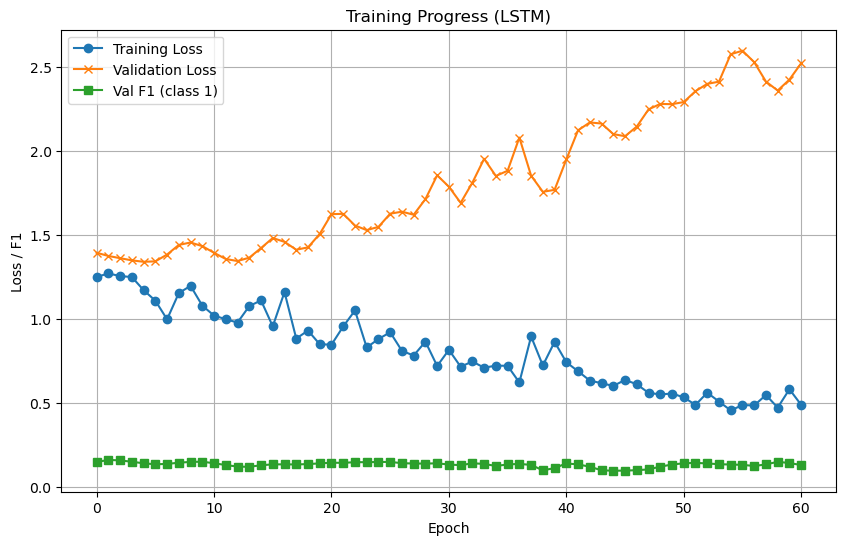

In [17]:

# =============================
# Plot training progress
# =============================
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='x')
plt.plot(val_f1_scores, label='Val F1 (class 1)', marker='s')
if demonstrate_early_stopping:
    plt.axvline(x=best_epoch, color='r', linestyle='--', label='Early Stop Point')
plt.title('Training Progress (LSTM)')
plt.xlabel('Epoch')
plt.ylabel('Loss / F1')
plt.legend()
plt.grid(True)
#plt.savefig("loss_curves_lstm.png")
plt.show()


In [15]:

# =============================
# Final Test Evaluation (preserved metrics & print format)
# =============================
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_pad, y_pad, mask, lengths in test_loader:
        X_pad, mask = X_pad.to(device), mask.to(device)
        logits = model(X_pad, lengths)                    # [B, T, 1]
        probs = torch.sigmoid(logits).squeeze(-1)         # [B, T]
        preds = (probs > THRESHOLD).float()               # [B, T]
        all_preds.extend(preds[mask].cpu().numpy())
        all_labels.extend(y_pad.squeeze(-1)[mask].cpu().numpy())

# Flatten to 1D numpy
all_preds  = torch.tensor(all_preds).view(-1).numpy()
all_labels = torch.tensor(all_labels).view(-1).numpy()

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Manual counts for class 1 ('C')
TP_c = ((all_preds == 1) & (all_labels == 1)).sum()
FN_c = ((all_preds == 0) & (all_labels == 1)).sum()
FP_c = ((all_preds == 1) & (all_labels == 0)).sum()

# Metrics (preserved)
precision_C = precision_score(all_labels, all_preds, pos_label=1)
recall_C = recall_score(all_labels, all_preds, pos_label=1)
f1_C = f1_score(all_labels, all_preds, pos_label=1)

accuracy = accuracy_score(all_labels, all_preds)
macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print("\n--- Detailed Evaluation on Test Set ---")
print(f"True Positives (C): {TP_c}")
print(f"False Positives (C): {FP_c}")
print(f"False Negatives (C): {FN_c}")
print(f"Precision (C): {precision_C:.4f}")
print(f"Recall (C): {recall_C:.4f}")
print(f"F1 Score (C): {f1_C:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro F1: {macro_f1:.4f}")



--- Detailed Evaluation on Test Set ---
True Positives (C): 41
False Positives (C): 342
False Negatives (C): 73
Precision (C): 0.1070
Recall (C): 0.3596
F1 Score (C): 0.1650
Accuracy: 0.9492
Macro Precision: 0.5488
Macro F1: 0.5694
